In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
import pandas_datareader.data as web

ff_data = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2019-01-01', end='2025-12-31')
print(ff_data.keys())
print(ff_data[0].head())

dict_keys([0, 1, 'DESCR'])
         Mkt-RF   SMB   HML    RF
Date                             
2019-01    8.37  2.76 -0.39  0.21
2019-02    3.42  2.05 -2.66  0.18
2019-03    1.10 -3.03 -4.14  0.19
2019-04    3.97 -1.74  2.13  0.21
2019-05   -6.92 -1.26 -2.45  0.21


In [3]:
ff_monthly = ff_data[0] / 100
print(ff_monthly.head())

         Mkt-RF     SMB     HML      RF
Date                                   
2019-01  0.0837  0.0276 -0.0039  0.0021
2019-02  0.0342  0.0205 -0.0266  0.0018
2019-03  0.0110 -0.0303 -0.0414  0.0019
2019-04  0.0397 -0.0174  0.0213  0.0021
2019-05 -0.0692 -0.0126 -0.0245  0.0021


In [4]:
tickers = ['GS', 'MSCI', 'V', 'CRISIL.NS', 'HDFCBANK.NS']
data = yf.download(tickers, start = '2019-01-01', end= '2026-01-01')['Close']
print(data.shape)
print(data.head())

/tmp/ipykernel_601/1821282761.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2019-01-01', end= '2026-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

(1816, 5)
Ticker        CRISIL.NS          GS  HDFCBANK.NS        MSCI           V
Date                                                                    
2019-01-01  1430.624512         NaN   496.185822         NaN         NaN
2019-01-02  1435.571289  144.753708   491.658447  135.801605  126.068062
2019-01-03  1447.056030  142.633255   487.800995  130.626068  121.525017
2019-01-04  1436.807983  147.294876   489.106079  135.487381  126.760452
2019-01-07  1448.645874  148.111038   489.845245  136.115845  129.046204


In [5]:
data.isnull().sum().sum()

np.int64(340)

In [6]:
data_clean = data.dropna()
print(data_clean.shape)

(1674, 5)


In [7]:
data_clean.isnull().sum().sum()

np.int64(0)

In [8]:
monthly_prices = data_clean.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna()
print(monthly_returns.shape)
print(monthly_returns.head())

(83, 5)
Ticker      CRISIL.NS        GS  HDFCBANK.NS      MSCI         V
Date                                                            
2019-02-28  -0.115640 -0.002604    -0.001154  0.088450  0.099019
2019-03-31   0.000435 -0.028063     0.108421  0.064530  0.044221
2019-04-30  -0.009843  0.077100     0.006362  0.146156  0.063102
2019-05-31   0.021271 -0.109788     0.046560 -0.021257 -0.017343
2019-06-30   0.020440  0.121157     0.013849  0.085360  0.075746


In [9]:
print(monthly_returns.index[:3])
print(ff_monthly.index[:3])

DatetimeIndex(['2019-02-28', '2019-03-31', '2019-04-30'], dtype='datetime64[ns]', name='Date', freq='ME')
PeriodIndex(['2019-01', '2019-02', '2019-03'], dtype='period[M]', name='Date')


In [10]:
monthly_returns.index = monthly_returns.index.to_period('M')
print(monthly_returns.index[:3])

PeriodIndex(['2019-02', '2019-03', '2019-04'], dtype='period[M]', name='Date')


In [11]:
combined = monthly_returns.join(ff_monthly, how='inner')
print(combined.shape)
print(combined.head())

(83, 9)
         CRISIL.NS        GS  HDFCBANK.NS      MSCI         V  Mkt-RF     SMB  \
Date                                                                            
2019-02  -0.115640 -0.002604    -0.001154  0.088450  0.099019  0.0342  0.0205   
2019-03   0.000435 -0.028063     0.108421  0.064530  0.044221  0.0110 -0.0303   
2019-04  -0.009843  0.077100     0.006362  0.146156  0.063102  0.0397 -0.0174   
2019-05   0.021271 -0.109788     0.046560 -0.021257 -0.017343 -0.0692 -0.0126   
2019-06   0.020440  0.121157     0.013849  0.085360  0.075746  0.0699  0.0011   

            HML      RF  
Date                     
2019-02 -0.0266  0.0018  
2019-03 -0.0414  0.0019  
2019-04  0.0213  0.0021  
2019-05 -0.0245  0.0021  
2019-06 -0.0064  0.0018  


In [12]:
for ticker in tickers:
    combined[f'{ticker}_excess'] = combined[ticker] - combined['RF']

print(combined[[f'{t}_excess' for t in tickers]].head())

         GS_excess  MSCI_excess  V_excess  CRISIL.NS_excess  \
Date                                                          
2019-02  -0.004404     0.086650  0.097219         -0.117440   
2019-03  -0.029963     0.062630  0.042321         -0.001465   
2019-04   0.075000     0.144056  0.061002         -0.011943   
2019-05  -0.111888    -0.023357 -0.019443          0.019171   
2019-06   0.119357     0.083560  0.073946          0.018640   

         HDFCBANK.NS_excess  
Date                         
2019-02           -0.002954  
2019-03            0.106521  
2019-04            0.004262  
2019-05            0.044460  
2019-06            0.012049  


In [13]:
import statsmodels.api as sm

X = combined[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)  # adds the alpha/intercept term
y = combined['GS_excess']

model_gs = sm.OLS(y, X).fit()
print(model_gs.summary())

                            OLS Regression Results                            
Dep. Variable:              GS_excess   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     83.87
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.74e-24
Time:                        08:22:29   Log-Likelihood:                 145.33
No. Observations:                  83   AIC:                            -282.7
Df Residuals:                      79   BIC:                            -273.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0075      0.005      1.526      0.1

In [14]:
results_summary = []

for ticker in tickers:
    y = combined[f'{ticker}_excess']
    model = sm.OLS(y, X).fit()
    results_summary.append({
        'Ticker': ticker,
        'Alpha': model.params['const'],
        'Alpha_pvalue': model.pvalues['const'],
        'Beta_Market': model.params['Mkt-RF'],
        'Beta_SMB': model.params['SMB'],
        'Beta_HML': model.params['HML'],
        'R_squared': model.rsquared
    })

results_df = pd.DataFrame(results_summary)
print(results_df)

        Ticker     Alpha  Alpha_pvalue  Beta_Market  Beta_SMB  Beta_HML  \
0           GS  0.007520      0.130953     1.348909  0.393434  0.524643   
1         MSCI  0.005075      0.453983     1.030052  0.110451 -0.360326   
2            V -0.000038      0.994119     0.946126 -0.444541  0.112085   
3    CRISIL.NS  0.014716      0.191167     0.191686  0.510911 -0.283920   
4  HDFCBANK.NS  0.002983      0.641030     0.564015  0.271502  0.372320   

   R_squared  
0   0.761046  
1   0.465881  
2   0.506993  
3   0.052827  
4   0.299502  


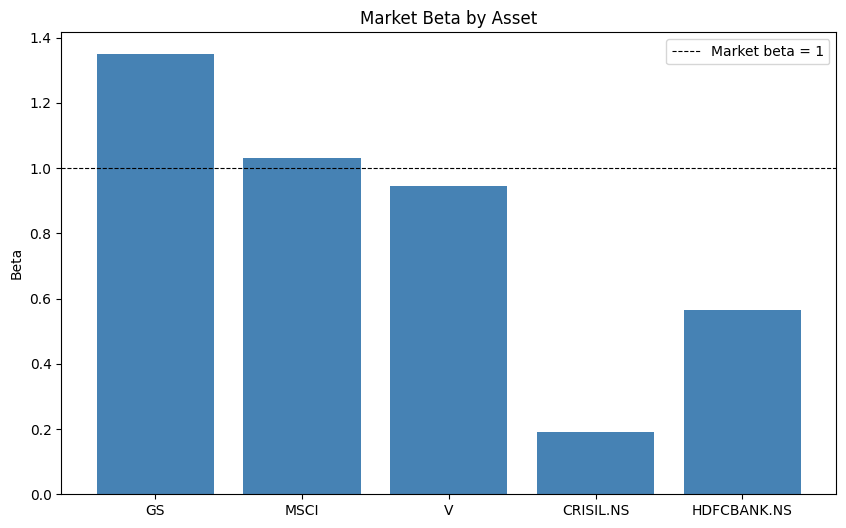

In [16]:
plt.figure(figsize=(10,6))
plt.bar(results_df['Ticker'], results_df['Beta_Market'], color='steelblue')
plt.axhline(y=1, color='black', linestyle='--', linewidth=0.8, label='Market beta = 1')
plt.title('Market Beta by Asset')
plt.ylabel('Beta')
plt.legend()
plt.show()

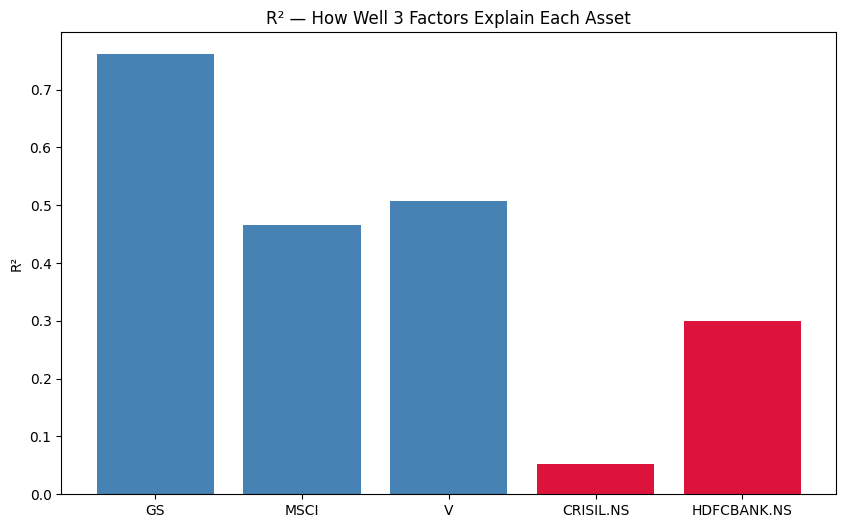

In [17]:
plt.figure(figsize=(10,6))
colors = ['steelblue', 'steelblue', 'steelblue', 'crimson', 'crimson']
plt.bar(results_df['Ticker'], results_df['R_squared'], color=colors)
plt.title('R² — How Well 3 Factors Explain Each Asset')
plt.ylabel('R²')
plt.show()